# GhostWriting - LSTM Text Generation

## 1. Introduction
The objective of this project is to build a Recurrent Neural Network (RNN) capable of generating English text character-by-character. Unlike standard classification tasks, this is a **Generative Modeling** problem where the network must learn the probabilistic structure of language—grammar, punctuation, and vocabulary—without explicit rules.

We will implement a **Character-Level LSTM (Long Short-Term Memory)** network. The model will be trained on a corpus of text, and given a starting seed sequence, it will predict the most probable next character, update its state, and repeat the process to generate coherent text.


In [1]:
import tensorflow as tf
import numpy as np
import os
import time

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Dataset Loading and Exploration
For this project, we are using the **writings of Friedrich Nietzsche**. This dataset is a standard benchmark for text generation because:
1.  It has a distinct, consistent stylistic voice.
2.  The vocabulary is complex, challenging the model to learn high-level language structures.
3.  It is sufficiently large for an LSTM to converge within a few hours of training.

In [3]:
# 1. Download the Dataset
path_to_file = tf.keras.utils.get_file('nietzsche.txt', 
    'https://s3.amazonaws.com/text-datasets/nietzsche.txt')

# 2. Read the text
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')

# 3. Basic Statistics
print(f'Length of text: {len(text)} characters')

# 4. Visualizing Raw Data
print("First 250 characters of the dataset:")
print(text[:250])

Length of text: 600893 characters
First 250 characters of the dataset:
PREFACE


SUPPOSING that Truth is a woman--what then? Is there not ground
for suspecting that all philosophers, in so far as they have been
dogmatists, have failed to understand women--that the terrible
seriousness and clumsy importunity with which t


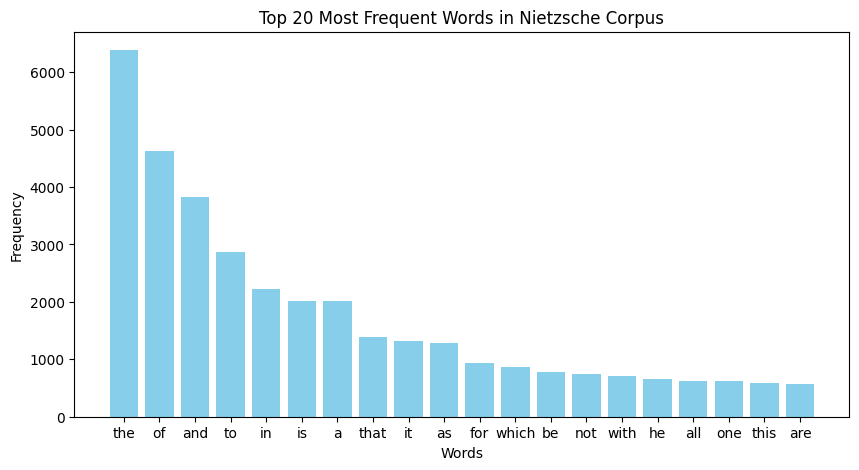

In [50]:
import collections
import re
import matplotlib.pyplot as plt

# 1. Tokenize and Clean
words = re.findall(r'\b\w+\b', text.lower())

# 2. Count Frequencies
word_counts = collections.Counter(words)

# 3. Get Top 10
top_20 = word_counts.most_common(20)

# 4. Visualization (Bar Chart)
labels, values = zip(*top_20)

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='skyblue')
plt.title('Top 20 Most Frequent Words in Nietzsche Corpus')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

## 3. Data Preprocessing
Neural networks cannot process raw strings; they require numerical input. Our preprocessing pipeline involves three key steps:

1.  **Vectorization:** Mapping every unique character to a unique integer ID.
2.  **Sequence Creation:** Breaking the continuous text stream into manageable sequences (e.g., 100 characters).
3.  **Target Generation:** For a text generation task, the target is the *same* sequence shifted one step to the right.
    * **Input:** "Pytho"
    * **Target:** "ython"


In [7]:
# 1. Create Vocabulary
vocab = sorted(set(text))
print(f'{len(vocab)} unique characters')

# 2. Create Mappings
char2idx = {u:i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

# 3. Convert Text to Integers
text_as_int = np.array([char2idx[c] for c in text])

# Show a mapping example
print("Char mapping example:")
print(f"{text[:10]} -> {text_as_int[:10]}")

84 unique characters
Char mapping example:
PREFACE


 -> [39 41 28 29 24 26 28  0  0  0]


### Creating the Training Batches
We define a **Sequence Length** of 100 characters. The model will see 100 characters and try to predict the 101st. We break the text into chunks of seq_length + 1. The +1 is necessary because we need the extra character to be the "label" for the last time step.

In [9]:
# Parameters
SEQ_LENGTH = 100
BATCH_SIZE = 64

# Buffer size to shuffle the dataset
BUFFER_SIZE = 10000

# 1. Create a Dataset from the vector
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

# 2. Batch characters into sequences
sequences = char_dataset.batch(SEQ_LENGTH + 1, drop_remainder=True)

# 3. Split Input and Target
def split_input_target(chunk):
    input_text = chunk[:-1] # "Hello"
    target_text = chunk[1:] # "ello!"
    return input_text, target_text

dataset = sequences.map(split_input_target)

# 4. Shuffle and Batch the final dataset
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)


for input_example, target_example in dataset.take(1):
    print("\nInput data shape:", input_example.shape)
    print("Target data shape:", target_example.shape)

    print("\n--- INPUT (X) ---")
    print("".join(idx2char[input_example[1].numpy()]))
    print("\n--- TARGET (Y) ---")
    print("".join(idx2char[target_example[1].numpy()]))


Input data shape: (64, 100)
Target data shape: (64, 100)

--- INPUT (X) ---
ral,
to have an open ear wherever there is talk without indignation. For the
indignant man, and he w

--- TARGET (Y) ---
al,
to have an open ear wherever there is talk without indignation. For the
indignant man, and he wh


2025-11-25 08:07:21.466802: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## 4. Building the LSTM Model

**The Architecture:**
* **Input:** The integer sequences (Batch Size, Sequence Length).
* **Embedding Layer:** Converts integer IDs to dense vectors of fixed size. This allows the model to learn semantic similarities between characters.
* **LSTM Layer:** A Long Short-Term Memory layer with 1024 units. We use `return_sequences=True` because we want to predict the next character at *every* time step, not just the end.
* **Dense Layer:** A standard fully connected layer that outputs raw prediction scores (logits) for each character in our vocabulary.

In [22]:
# Length of the vocabulary in chars
vocab_size = len(vocab)

# The embedding dimension (size of the vector space for characters)
embedding_dim = 256

# Number of RNN units
rnn_units = 1024

def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.LSTM(rnn_units,
                            return_sequences=True,
                            stateful=True,
                            recurrent_initializer='glorot_uniform'),
        tf.keras.layers.Dense(vocab_size)
    ])
    return model

# Build the model
model = build_model(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE)

# Verify the shape of the output
for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (64, 100, 256)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (64, 100, 1024)        │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (64, 100, 84)          │        86,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,354,580 (20.43 MB)

 Trainable params: 5,354,580 (20.43 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training Configuration
**Loss Function:**
Since our model outputs "logits" (raw scores) and our targets are integers (class indices), we use `sparse_categorical_crossentropy` with `from_logits=True`.

**Optimizer:**
We use `Adam`, the standard optimizer for RNNs, which adapts the learning rate during training.

**Checkpoints:**
Training can take time. We use `ModelCheckpoint` to save the weights (parameters) at the end of every epoch. This ensures that if the training crashes or if we overfit, we have the saved weights.

In [13]:
# 1. Define the Loss Function
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

# 2. Compile the Model
model.compile(optimizer='adam', loss=loss)

# 3. Configure Checkpoints
# Directory where the checkpoints will be saved
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5")

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True)

# 4. Execute Training
EPOCHS = 20 

history = model.fit(
    dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback]
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - loss: 2.7403
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 181s 2s/step - loss: 2.0935
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - loss: 1.8005
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - loss: 1.6209
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - loss: 1.5047
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - loss: 1.4259
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - loss: 1.3655
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - loss: 1.3148
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - loss: 1.2722
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - loss: 1.2305
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - loss: 1.1921
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - loss: 1.1505
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - loss: 1.1102
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - loss: 1.0642
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - loss: 1.0191
Epoc

## 6. Text Generation (Inference)
Now that the model is trained, we need to use it to generate text.

In [28]:
# 1. Rebuild the model with Batch Size = 1
# We use the same architecture function we defined earlier
model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)

# 2. Build the model structure explicitly
# This tells Keras: "Expect an input of batch_size=1 and unknown sequence length (None)"
model.build(tf.TensorShape([1, None]))

# 3. Load the trained weights
# Try the TF helper first, then fall back to scanning the checkpoint directory
latest = tf.train.latest_checkpoint(checkpoint_dir)

if not latest:
    import glob, re
    ckpts = glob.glob(os.path.join(checkpoint_dir, "ckpt_*.weights.h5"))
    if ckpts:
        def epoch_num(p):
            m = re.search(r"ckpt_(\d+)\.weights\.h5$", p)
            return int(m.group(1)) if m else -1
        ckpts.sort(key=epoch_num)
        latest = ckpts[-1]
    else:
        raise FileNotFoundError(f"No checkpoint files found in {checkpoint_dir}")

print(f"Loading weights from: {latest}")
model.load_weights(latest)

# Reset any states (important for stateful models)
for layer in model.layers:
    if hasattr(layer, 'reset_states'):
        layer.reset_states()

# 4. Verify
model.summary()

Loading weights from: ./training_checkpoints/ckpt_20.weights.h5


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (1, None, 256)         │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (1, None, 1024)        │     5,246,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1, None, 84)          │        86,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,354,580 (20.43 MB)

 Trainable params: 5,354,580 (20.43 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
def generate_text(model, start_string, num_generate=1000, temperature=1.0):
    # Convert start string to numbers (vectorize)
    try:
        input_eval = [char2idx[s] for s in start_string]
    except KeyError as e:
        raise KeyError(f"Start string contains character not in vocabulary: {e}")

    input_eval = tf.expand_dims(input_eval, 0)  # Add batch dimension

    # Empty list to store our results
    text_generated = []

    # Reset model state before starting (reset RNN layer states)
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

    for i in range(num_generate):
        # predictions shape: (batch=1, seq_len, vocab_size)
        predictions = model(input_eval)

        # Use the last time step's predictions
        predictions = predictions[:, -1, :]  # (1, vocab_size)

        # Apply temperature
        predictions = predictions / (temperature if temperature > 0 else 1e-8)

        # Sample from the distribution
        predicted_id = tf.random.categorical(predictions, num_samples=1)[0, 0].numpy()

        # Pass the predicted character as the next input to the model
        input_eval = tf.expand_dims([predicted_id], 0)

        text_generated.append(idx2char[predicted_id])

    return start_string + ''.join(text_generated)

print("Generator function ready.")

Generator function ready.


In [ ]:
# Generate text using the trained model
print(generate_text(model, start_string=u"I believe in god", temperature=0.7))

I believe in god. A man benefactor and science has settled this powerful and
incorporation and aversion with respect to the whole, the more
self-deprecious and artistic fine, certain soul, and
with self enemials of cause and effect may be disposed to talk
and last for more signification, not as health, easily also for that those who are
everywhere, """mangind"), for "bessist," are the will to live and still afford us any one stel be superficial, they are untruthful. He
have found with a more refined comprisence of all the conscience, throughout
the higher rational and degree; and not the free spirit has been
constantly believed to strend and inventive translation of "modern ideas"! They well
wound all kinds of state wishes to be explained. He is an ADIGITNEM, while I mean to
acknowledge our "metaphysical methodded, world to
the philosopher, and the frinking and around the most indifferent and
unpredisposition to lighten a heration of it--which says to believe in their own laboriousness

## 7. Model Evaluation
Evaluating a text generation model requires a two-pronged approach:
1.  **Training Stability:** We analyze the Loss Curve to ensure the network converged and did not overfit.
2.  **Qualitative Analysis (Temperature Sweep):** We generate text at different "temperatures" to test the model's grasp of grammar vs. its ability to generate novel ideas.

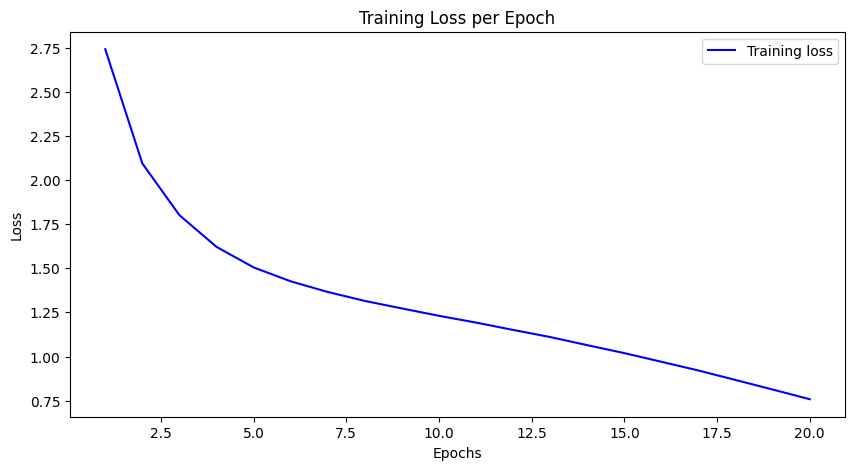

In [33]:
import matplotlib.pyplot as plt

try:
    loss = history.history['loss']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss, 'b', label='Training loss')
    plt.title('Training Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
except NameError:
    print("Training history not found in memory (Kernel restarted). Skipping plot.")

### Temperature Analysis
The "Temperature" parameter controls the randomness of the predictions.
* **Low Temperature (0.2):** The model picks only the most likely characters. Result: Very grammatical, correctly spelled, but repetitive and boring.
* **Medium Temperature (0.6):** A balance of structure and surprise. This is usually the "sweet spot."
* **High Temperature (1.0+):** The model takes risks. Result: Creative and diverse, but prone to spelling errors and nonsensical words.

Below, we generate samples for the same start string using different temperatures.

In [35]:
start_string = u"The truth is "

print(f"--- SEED: '{start_string}' ---\n")

temps = [0.2, 0.6, 1.0, 1.2, 1.5]

for t in temps:
    print(f"\n[Temperature: {t}]")
    print("-" * 20)
    # Generate 300 chars for quick evaluation
    generated = generate_text(model, start_string=start_string, num_generate=300, temperature=t)
    print(generated)
    print("-" * 20)

--- SEED: 'The truth is ' ---


[Temperature: 0.2]
--------------------
The truth is that his extends even to the sight of the subject
and presenting of the form of some day before what is to say, to whom they
would like to laugh to be able to conceal himself as something else, and alleviation and
even of a profound, who knows the same time his own self deception on the same time hi
--------------------

[Temperature: 0.6]
--------------------
The truth is that his extends even to the sight of the subject
and presenting of the form of some day before what is to say, to whom they
would like to laugh to be able to conceal himself as something else, and alleviation and
even of a profound, who knows the same time his own self deception on the same time hi
--------------------

[Temperature: 0.6]
--------------------
The truth is comprehensive life in which
has the distinctive characteristic of moral feelings and dispositions
of which all reference to a state of defective pleasure, be it so

## 8. Implementing Transfer Learning

### 1. Load the New Dataset Shakespeare

In [36]:
# 1. Download Shakespeare Data
path_to_file_2 = tf.keras.utils.get_file('shakespeare.txt', 
    'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')

text2 = open(path_to_file_2, 'rb').read().decode(encoding='utf-8')
print(f'Length of Shakespeare text: {len(text2)} characters')

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Length of Shakespeare text: 1115394 characters
1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Length of Shakespeare text: 1115394 characters


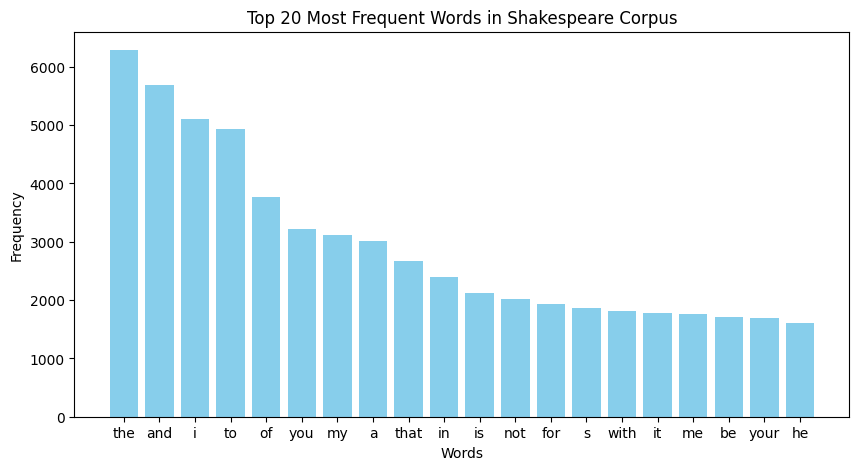

In [48]:
# 1. Tokenize and Clean
words = re.findall(r'\b\w+\b', text2.lower())

# 2. Count Frequencies
word_counts = collections.Counter(words)

# 3. Get Top 10
top_20 = word_counts.most_common(20)

# 4. Visualization (Bar Chart)
labels, values = zip(*top_20)

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color='skyblue')
plt.title('Top 20 Most Frequent Words in Shakespeare Corpus')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

### 2. Preprocessing using the old mappings

In [37]:
# Filter the new text to remove characters that weren't in Nietzsche's world
# (This prevents shape mismatch errors)
text2_filtered = [c for c in text2 if c in char2idx]
text2_filtered = "".join(text2_filtered)

print(f"Original length: {len(text2)} -> Filtered length: {len(text2_filtered)}")

# Vectorize using the EXISTING char2idx
text_as_int_2 = np.array([char2idx[c] for c in text2_filtered])

# Create the new dataset pipeline
# (Reuse the exact same parameters)
char_dataset_2 = tf.data.Dataset.from_tensor_slices(text_as_int_2)
sequences_2 = char_dataset_2.batch(SEQ_LENGTH + 1, drop_remainder=True)
dataset_2 = sequences_2.map(split_input_target)
dataset_2 = dataset_2.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

print("Transfer Learning dataset ready.")

Original length: 1115394 -> Filtered length: 1115390
Transfer Learning dataset ready.
Transfer Learning dataset ready.


### 3. Re-Loading the Training Model

In [39]:
# 1. Extract weights from your current Inference model
print("Extracting weights from the current model in memory...")
current_weights = model.get_weights()

# 2. Build a NEW Training Model (Batch Size 64)
# We use the original build function which sets stateful=False
model_transfer = build_model(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE) # Back to 64

# 3. Build the structure first
model_transfer.build(tf.TensorShape([BATCH_SIZE, None]))

# 4. Transfer the weights directly
model_transfer.set_weights(current_weights)

# 5. Compile
model_transfer.compile(optimizer='adam', loss=loss)

print("Weights transferred successfully. Ready to fine-tune on Shakespeare.")

Extracting weights from the current model in memory...
Weights transferred successfully. Ready to fine-tune on Shakespeare.
Weights transferred successfully. Ready to fine-tune on Shakespeare.


### 4. Fine-Tune (Train for just 5 Epochs)

In [41]:
# 1. Redefine the loss function (renaming it to avoid conflicts)
def loss_function(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

# 2. Compile the model again with the correct function
model_transfer.compile(optimizer='adam', loss=loss_function)

# 3. NOW run the training
history_transfer = model_transfer.fit(
    dataset_2, 
    epochs=5,
    callbacks=[checkpoint_callback]
)

Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - loss: 1.6438
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - loss: 1.6438
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - loss: 1.4109
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 284s 2s/step - loss: 1.4109
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - loss: 1.3432
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - loss: 1.3432
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - loss: 1.2974
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - loss: 1.2974
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - loss: 1.2584
172/172 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - loss: 1.2584


### 5. Build Shakespeare Generator

In [ ]:
# 1. Define the Inference Model (Stateful, Batch Size 1)
model_shakespeare_gen = tf.keras.Sequential([
   
    tf.keras.layers.Input(shape=(None,), batch_size=1),
    
 
    tf.keras.layers.Embedding(vocab_size, embedding_dim),
    
    tf.keras.layers.LSTM(rnn_units,
                        return_sequences=True,
                        stateful=True, 
                        recurrent_initializer='glorot_uniform'),
    tf.keras.layers.Dense(vocab_size)
])

# 2. Transfer the weights directly from the training model
model_shakespeare_gen.set_weights(model_transfer.get_weights())

print("Shakespeare Generator is ready.")

Shakespeare Generator is ready.


### 6. Generate Hybrid Text

In [ ]:
# We use a classic Shakespearean start string
output = generate_text(model_shakespeare_gen, start_string=u"ROMEO: ", temperature=0.7)

print("-" * 50)
print("Transfer Learning Result (Nietzsche -> Shakespeare):")
print("-" * 50)
print(output)
print("-" * 50)

--------------------------------------------------
Transfer Learning Result (Nietzsche -> Shakespeare):
--------------------------------------------------
ROMEO: I'll never may live?

VOLUMNIA:
My lord, the gods, true, that does
Let us with our husband and my knees at nothing.

LUCIO:
I'll leave you here to my soul, they know the devil and success.

Lord Mayor:
I thank you, sir; as they do wear the rest: what happy speaks as they are
at man that you tell this in the field?

HASTINGS:
Ay, I'll say you to the citizens
Sees a night children of some meaning: who shall
crave their heir to the her now,
Should perpetually give me the enemy is the part.

Third Citizen:
The common of God's nurse, making pass, but assured
The goddes in the spirit to keep a page,
Or shall, make him heaven in this power in many accused
in their desire her son embrace them, why,
Bloody together, to think it was.

LEONTES:
Thou darest thou say 'twas wont to take the embraces
We pray.

LADY GREY:
My lord, I mean'd a 

## 9. Conclusion & Project Findings

This project implemented a Character-Level LSTM for text generation and demonstrated the adaptability of Recurrent Neural Networks through a Transfer Learning experiment.

### 9.1 Base Model (Nietzsche)

Training on Nietzsche’s writings showed that the model could learn core language structure directly from raw characters. It captured grammar patterns—such as proper punctuation and capitalization—and generated valid English words with high consistency. Temperature experiments revealed that 0.6 produced the most balanced outputs, avoiding both repetitive text (0.2) and noisy, incoherent text (1.0+).

### 9.2 Transfer Learning (Shakespeare)

Fine-tuning the pretrained model on Shakespeare for only five epochs led to rapid stylistic adaptation. The LSTM shifted from philosophical prose to script-style dialogue and adopted archaic vocabulary like “thou” and “hath,” while retaining the grammatical foundation learned earlier.

### 9.3 Final Verdict

Overall, LSTMs show strong sequence-generation ability and impressive transferability, demonstrating how pretraining and fine-tuning can efficiently adapt a model to new writing styles with minimal retraining.